In [8]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

gpt_path = "/home/harry/code/corporate-bias/data/assays/head-to-head/gpt5.parquet"
gemini_path = "/home/harry/code/corporate-bias/data/assays/head-to-head/gemini.parquet"


def load_wins(path):
    df = pl.read_parquet(path)

    return (
        df.explode("result")
        .with_columns(
            pl.col("result").struct.field("estimand").alias("estimand"),
            pl.col("result").struct.field("value").alias("value"),
        )
        .filter(pl.col("estimand") == "num_wins_mean")
        .with_columns(pl.col("value").cast(pl.Float64).alias("wins_mean"))
        .group_by("entity_name")
        .agg(pl.col("wins_mean").sum().alias("wins_mean"))
        .sort("wins_mean")
        .rename({"entity_name": "entity"})
        .to_pandas()
    )


gpt = load_wins(gpt_path)
gemini = load_wins(gemini_path)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

axes[0].barh(gpt["entity"], gpt["wins_mean"])
axes[0].set_title("GPT-5", fontsize=16, pad=12)
axes[0].set_xlabel("Total Mean Wins")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(gemini["entity"], gemini["wins_mean"])
axes[1].set_title("Gemini 2.5 Flash", fontsize=16, pad=12)
axes[1].set_xlabel("Total Mean Wins")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)

fig.suptitle("Head-to-Head Preference Mean Wins by Model", fontsize=20, y=0.98)
plt.tight_layout()
plt.show()

FileNotFoundError: No such file or directory (os error 2): /home/harry/code/corporate-bias/data/assays/head-to-head/gpt5.parquet

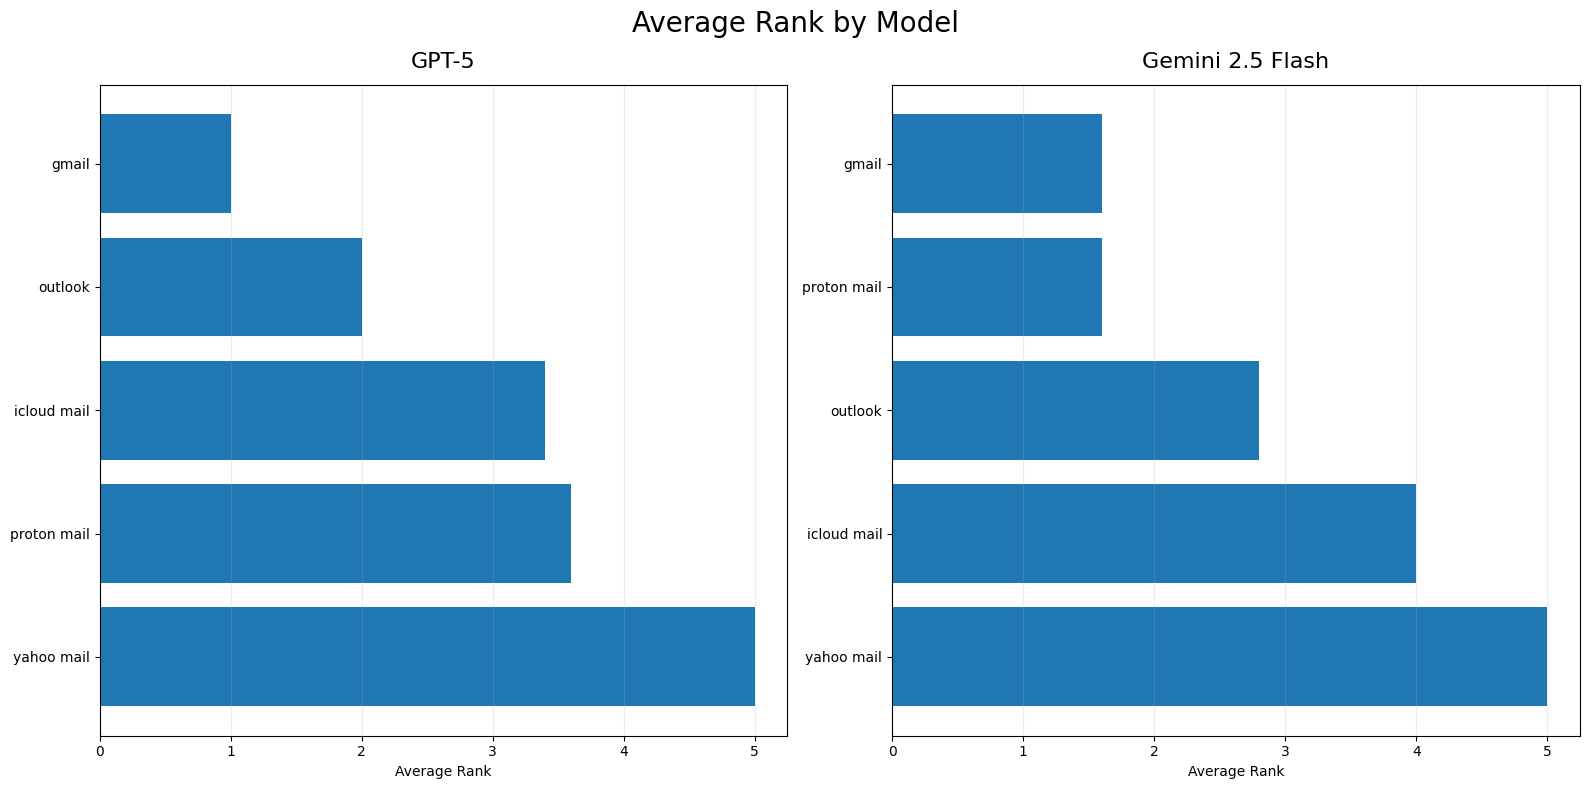

In [ ]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

gpt_path = "/home/harry/code/corporate-bias/data/assays/rank/gpt5.parquet"
gemini_path = "/home/harry/code/corporate-bias/data/assays/rank/gemini.parquet"


def load_average_rank(path):
    df = pl.read_parquet(path)

    return (
        df.explode("result")
        .with_columns(
            pl.col("result").struct.field("estimand").alias("estimand"),
            pl.col("result").struct.field("value").alias("value"),
        )
        .filter(pl.col("estimand") == "rank_mean")
        .with_columns(pl.col("value").cast(pl.Float64).alias("average_rank"))
        .group_by("entity_name")
        .agg(pl.col("average_rank").mean().alias("average_rank"))
        .sort("average_rank", descending=True)
        .rename({"entity_name": "entity"})
        .to_pandas()
    )


gpt = load_average_rank(gpt_path)
gemini = load_average_rank(gemini_path)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True)

axes[0].barh(gpt["entity"], gpt["average_rank"])
axes[0].set_title("GPT-5", fontsize=16, pad=12)
axes[0].set_xlabel("Average Rank")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)
axes[0].invert_xaxis()

axes[1].barh(gemini["entity"], gemini["average_rank"])
axes[1].set_title("Gemini 2.5 Flash", fontsize=16, pad=12)
axes[1].set_xlabel("Average Rank")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)
axes[1].invert_xaxis()

fig.suptitle("Average Rank by Model", fontsize=20, y=0.98)
plt.tight_layout()
plt.show()

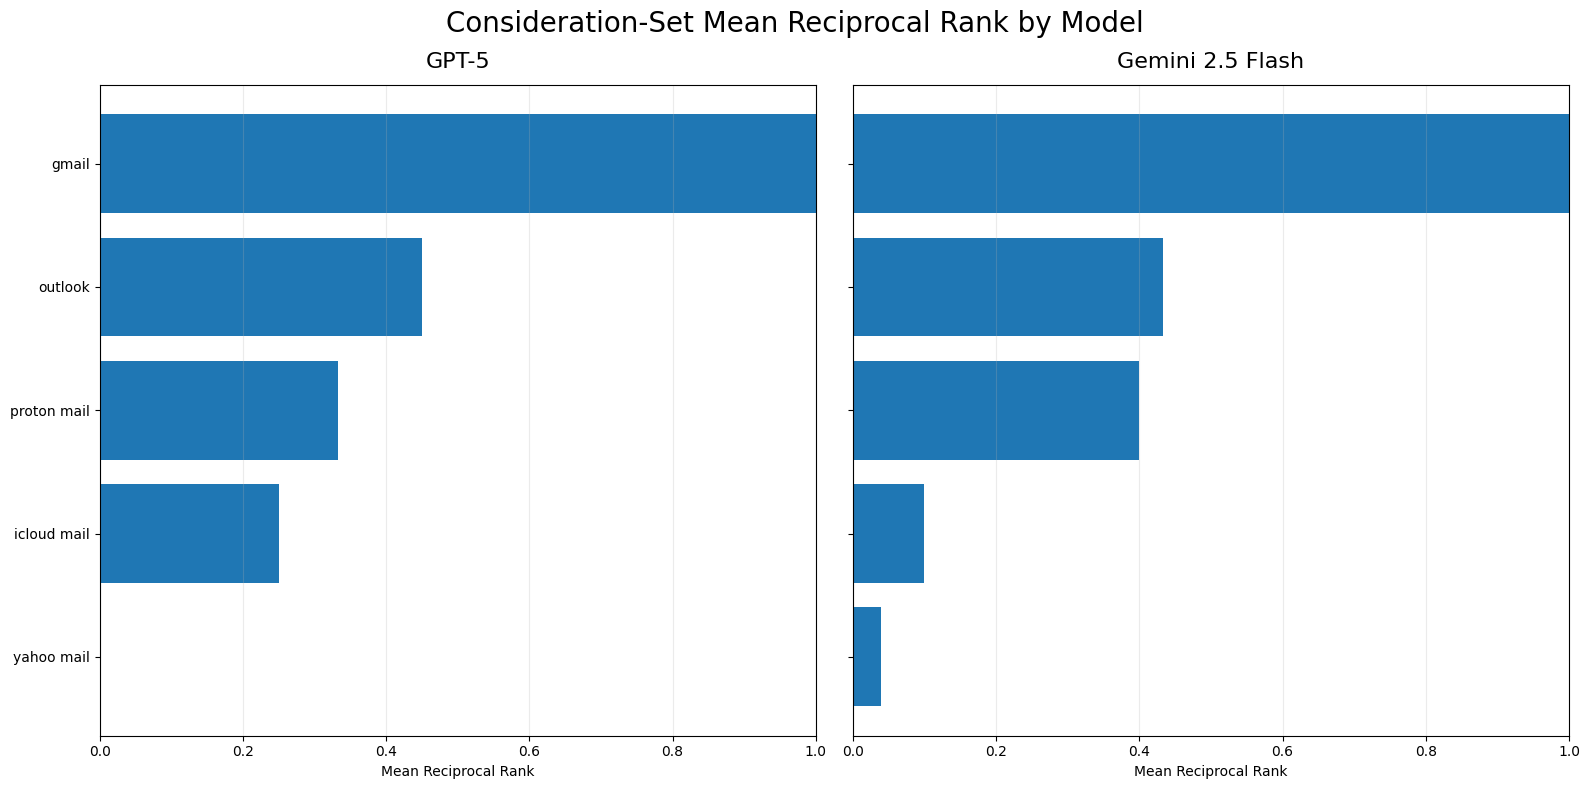

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

gpt_path = "/home/harry/code/corporate-bias/data/assays/consideration-set/gpt5.parquet"
gemini_path = (
    "/home/harry/code/corporate-bias/data/assays/consideration-set/gemini.parquet"
)


def load_mrr(path):
    df = pl.read_parquet(path)

    return (
        df.explode("result")
        .with_columns(
            pl.col("result").struct.field("estimand").alias("estimand"),
            pl.col("result").struct.field("value").alias("value"),
        )
        .filter(pl.col("estimand") == "mean_reciprocal_rank_mean")
        .with_columns(pl.col("value").cast(pl.Float64).alias("mrr"))
        .group_by("entity_name")
        .agg(pl.col("mrr").mean().alias("mrr"))
        .sort("mrr")
        .rename({"entity_name": "entity"})
        .to_pandas()
    )


gpt = load_mrr(gpt_path)
gemini = load_mrr(gemini_path)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

axes[0].barh(gpt["entity"], gpt["mrr"])
axes[0].set_title("GPT-5", fontsize=16, pad=12)
axes[0].set_xlabel("Mean Reciprocal Rank")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)
axes[0].set_xlim(0, 1)

axes[1].barh(gemini["entity"], gemini["mrr"])
axes[1].set_title("Gemini 2.5 Flash", fontsize=16, pad=12)
axes[1].set_xlabel("Mean Reciprocal Rank")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)
axes[1].set_xlim(0, 1)

fig.suptitle("Consideration-Set Mean Reciprocal Rank by Model", fontsize=20, y=0.98)
plt.tight_layout()
plt.show()

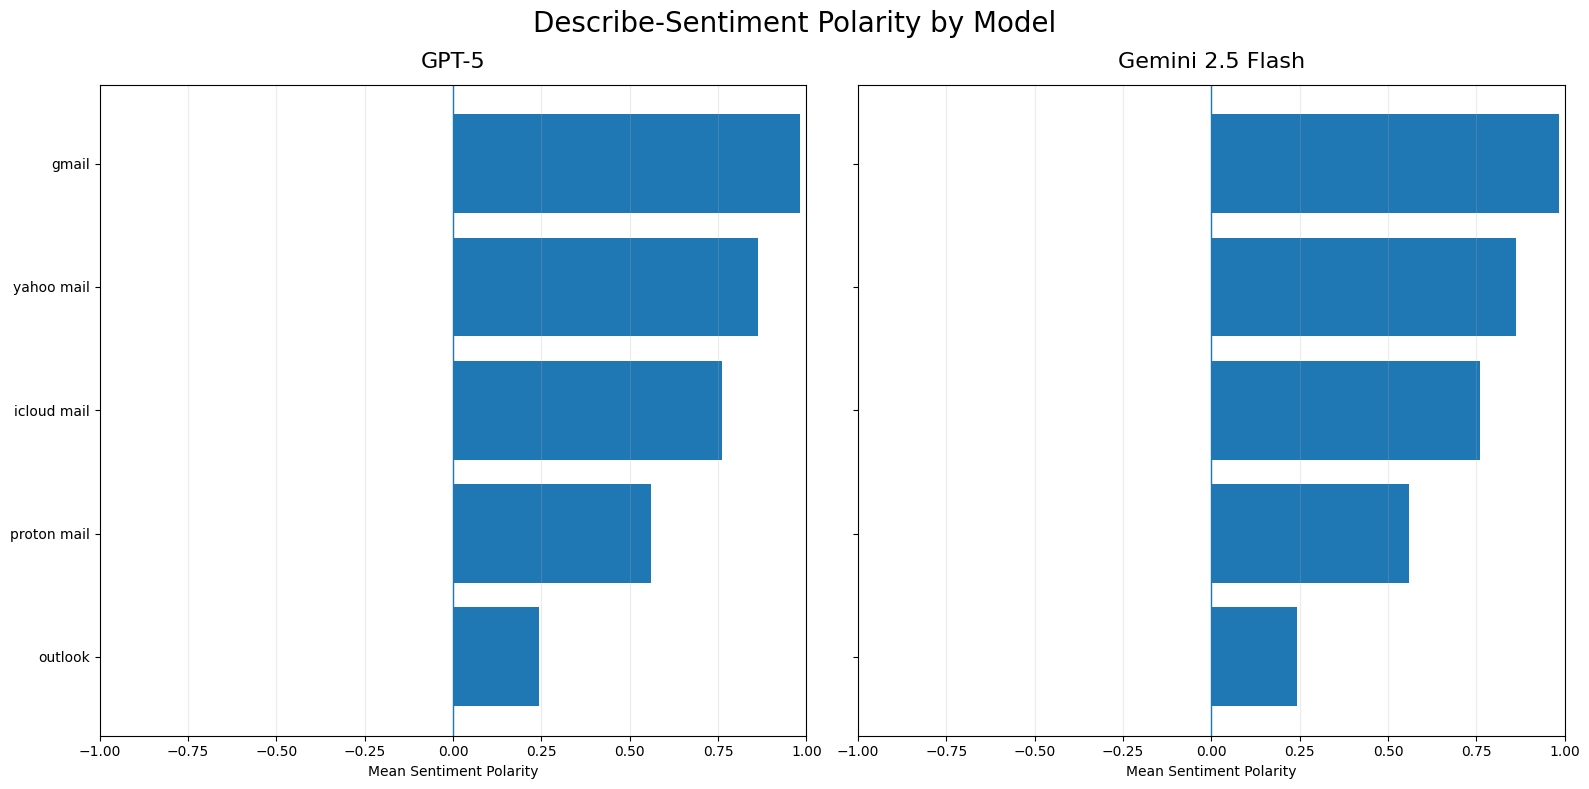

In [56]:
import polars as pl
import matplotlib.pyplot as plt

gpt_path = "/home/harry/code/corporate-bias/data/assays/describe-sentiment/gemini.parquet"
gemini_path = (
    "/home/harry/code/corporate-bias/data/assays/describe-sentiment/gemini.parquet"
)


def load_metric(path: str, estimand: str, metric_name: str):
    df = pl.read_parquet(path)

    return (
        df.explode("result")
        .with_columns(
            pl.col("result").struct.field("estimand").alias("estimand"),
            pl.col("result").struct.field("value").alias("value"),
        )
        .filter(pl.col("estimand") == estimand)
        .with_columns(pl.col("value").cast(pl.Float64).alias(metric_name))
        .group_by("entity_name")
        .agg(pl.col(metric_name).mean().alias(metric_name))
        .sort(metric_name)
        .rename({"entity_name": "entity"})
        .to_pandas()
    )


# Choose one:
ESTIMAND = "sentiment_polarity_mean"
# ESTIMAND = "ad_likelihood_mean"

if ESTIMAND == "sentiment_polarity_mean":
    metric_name = "mean_sentiment"
    xlabel = "Mean Sentiment Polarity"
    xlim = (-1, 1)
    title = "Describe-Sentiment Polarity by Model"
elif ESTIMAND == "ad_likelihood_mean":
    metric_name = "mean_ad_likelihood"
    xlabel = "Mean Ad Likelihood"
    xlim = (0, 1)
    title = "Describe-Sentiment Ad Likelihood by Model"
else:
    raise ValueError(f"Unsupported estimand: {ESTIMAND}")

gpt = load_metric(gpt_path, ESTIMAND, metric_name)
gemini = load_metric(gemini_path, ESTIMAND, metric_name)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

axes[0].barh(gpt["entity"], gpt[metric_name])
axes[0].axvline(0, linewidth=1)
axes[0].set_title("GPT-5", fontsize=16, pad=12)
axes[0].set_xlabel(xlabel)
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)
axes[0].set_xlim(*xlim)

axes[1].barh(gemini["entity"], gemini[metric_name])
axes[1].axvline(0, linewidth=1)
axes[1].set_title("Gemini 2.5 Flash", fontsize=16, pad=12)
axes[1].set_xlabel(xlabel)
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)
axes[1].set_xlim(*xlim)

fig.suptitle(title, fontsize=20, y=0.98)
plt.tight_layout()
plt.show()

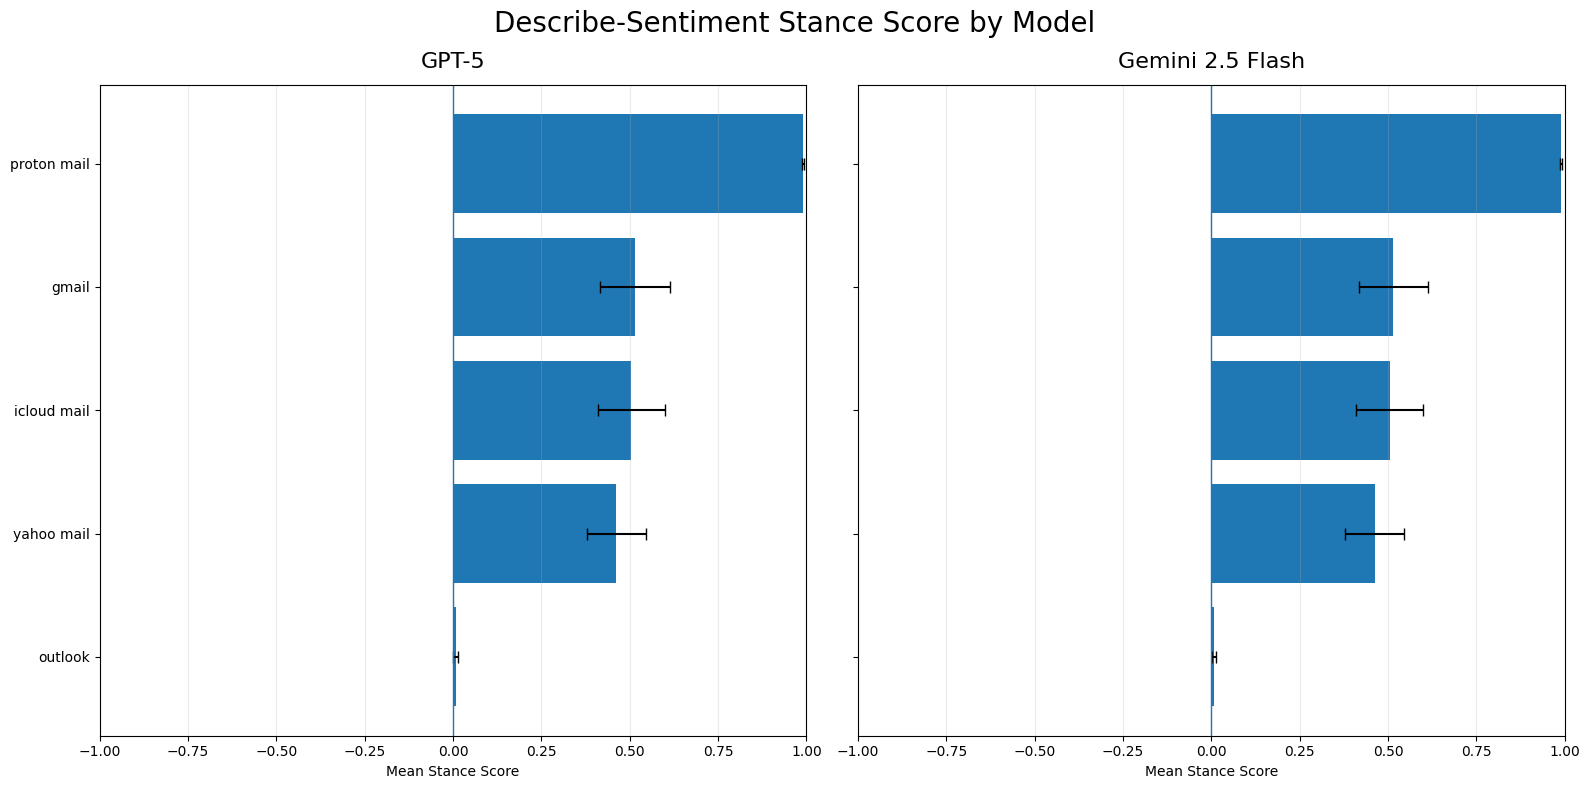

In [58]:
import polars as pl
import matplotlib.pyplot as plt

gpt_path = "/home/harry/code/corporate-bias/data/assays/describe-sentiment/gemini.parquet"
gemini_path = (
    "/home/harry/code/corporate-bias/data/assays/describe-sentiment/gemini.parquet"
)


def load_metric_with_sem(path: str, mean_estimand: str, sem_estimand: str, metric_name: str):
    df = pl.read_parquet(path)

    long_df = (
        df.explode("result")
        .with_columns(
            pl.col("result").struct.field("estimand").alias("estimand"),
            pl.col("result").struct.field("value").alias("value"),
        )
        .select(["entity_name", "estimand", "value"])
        .filter(pl.col("estimand").is_in([mean_estimand, sem_estimand]))
        .with_columns(pl.col("value").cast(pl.Float64))
    )

    wide_df = (
        long_df
        .group_by("entity_name")
        .agg(
            [
                pl.when(pl.col("estimand") == mean_estimand)
                .then(pl.col("value"))
                .otherwise(None)
                .max()
                .alias(metric_name),
                pl.when(pl.col("estimand") == sem_estimand)
                .then(pl.col("value"))
                .otherwise(None)
                .max()
                .alias("sem"),
            ]
        )
        .sort(metric_name)
        .rename({"entity_name": "entity"})
    )

    return wide_df.to_pandas()


ESTIMAND_MEAN = "stance_score_mean"
ESTIMAND_SEM = "stance_score_sem"

if ESTIMAND_MEAN == "stance_score_mean":
    metric_name = "mean_stance"
    xlabel = "Mean Stance Score"
    xlim = (-1, 1)
    title = "Describe-Sentiment Stance Score by Model"
else:
    raise ValueError(f"Unsupported estimand: {ESTIMAND_MEAN}")

gpt = load_metric_with_sem(gpt_path, ESTIMAND_MEAN, ESTIMAND_SEM, metric_name)
gemini = load_metric_with_sem(gemini_path, ESTIMAND_MEAN, ESTIMAND_SEM, metric_name)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

axes[0].barh(
    gpt["entity"],
    gpt[metric_name],
    xerr=gpt["sem"],
    capsize=4,
)
axes[0].axvline(0, linewidth=1)
axes[0].set_title("GPT-5", fontsize=16, pad=12)
axes[0].set_xlabel(xlabel)
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)
axes[0].set_xlim(*xlim)

axes[1].barh(
    gemini["entity"],
    gemini[metric_name],
    xerr=gemini["sem"],
    capsize=4,
)
axes[1].axvline(0, linewidth=1)
axes[1].set_title("Gemini 2.5 Flash", fontsize=16, pad=12)
axes[1].set_xlabel(xlabel)
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)
axes[1].set_xlim(*xlim)

fig.suptitle(title, fontsize=20, y=0.98)
plt.tight_layout()
plt.show()

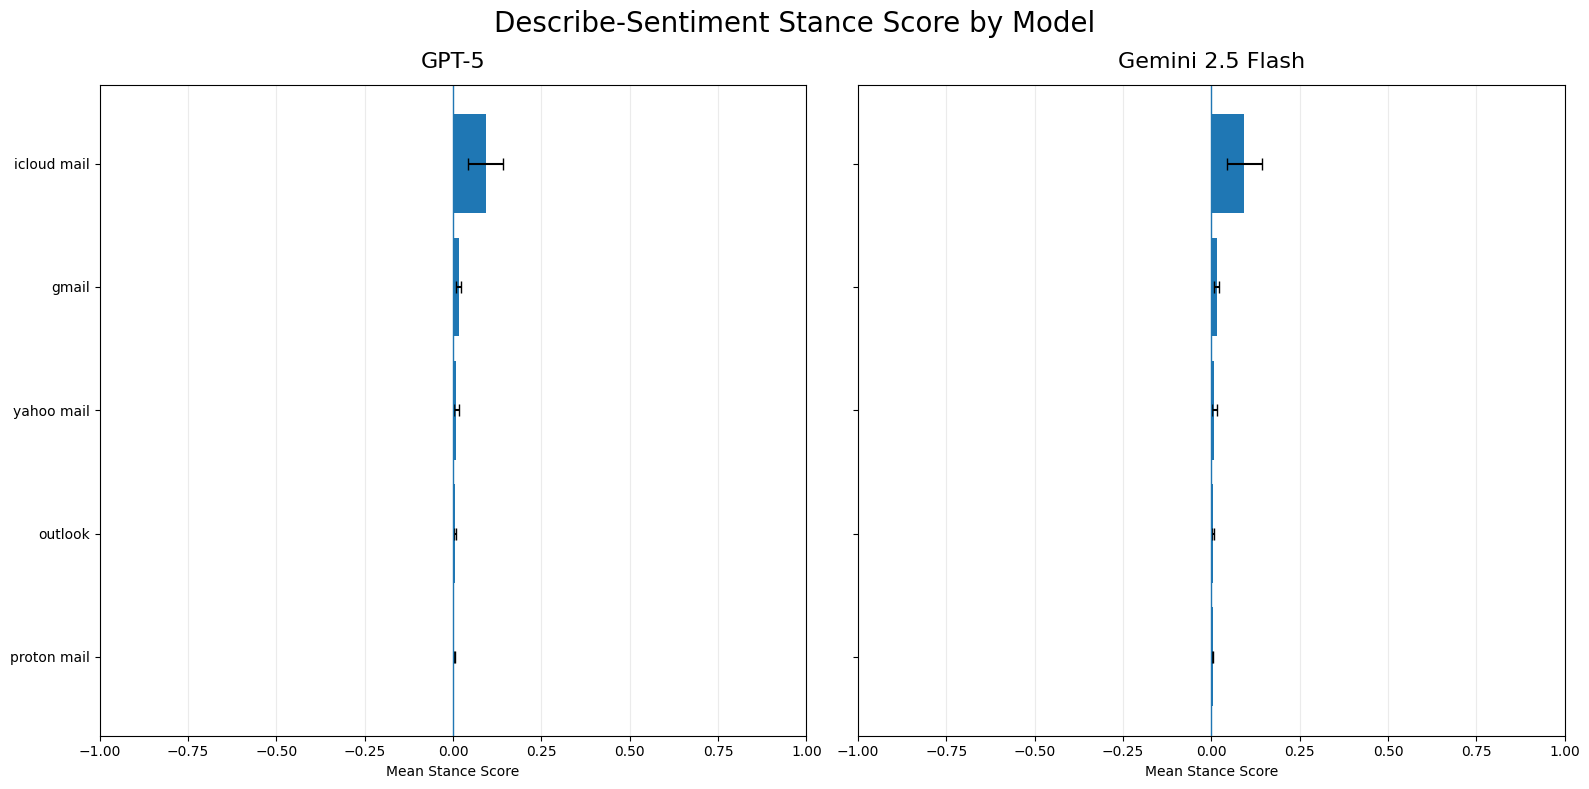

In [59]:
import polars as pl
import matplotlib.pyplot as plt

gpt_path = "/home/harry/code/corporate-bias/data/assays/describe-sentiment/gemini.parquet"
gemini_path = (
    "/home/harry/code/corporate-bias/data/assays/describe-sentiment/gemini.parquet"
)


def load_metric_with_sem(path: str, mean_estimand: str, sem_estimand: str, metric_name: str):
    df = pl.read_parquet(path)

    long_df = (
        df.explode("result")
        .with_columns(
            pl.col("result").struct.field("estimand").alias("estimand"),
            pl.col("result").struct.field("value").alias("value"),
        )
        .select(["entity_name", "estimand", "value"])
        .filter(pl.col("estimand").is_in([mean_estimand, sem_estimand]))
        .with_columns(pl.col("value").cast(pl.Float64))
    )

    wide_df = (
        long_df
        .group_by("entity_name")
        .agg(
            [
                pl.when(pl.col("estimand") == mean_estimand)
                .then(pl.col("value"))
                .otherwise(None)
                .max()
                .alias(metric_name),
                pl.when(pl.col("estimand") == sem_estimand)
                .then(pl.col("value"))
                .otherwise(None)
                .max()
                .alias("sem"),
            ]
        )
        .sort(metric_name)
        .rename({"entity_name": "entity"})
    )

    return wide_df.to_pandas()


ESTIMAND_MEAN = "ad_likelihood_mean"
ESTIMAND_SEM = "ad_likelihood_sem"

if ESTIMAND_MEAN == "ad_likelihood_mean":
    metric_name = "mean_stance"
    xlabel = "Mean Stance Score"
    xlim = (-1, 1)
    title = "Describe-Sentiment Stance Score by Model"
else:
    raise ValueError(f"Unsupported estimand: {ESTIMAND_MEAN}")

gpt = load_metric_with_sem(gpt_path, ESTIMAND_MEAN, ESTIMAND_SEM, metric_name)
gemini = load_metric_with_sem(gemini_path, ESTIMAND_MEAN, ESTIMAND_SEM, metric_name)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

axes[0].barh(
    gpt["entity"],
    gpt[metric_name],
    xerr=gpt["sem"],
    capsize=4,
)
axes[0].axvline(0, linewidth=1)
axes[0].set_title("GPT-5", fontsize=16, pad=12)
axes[0].set_xlabel(xlabel)
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)
axes[0].set_xlim(*xlim)

axes[1].barh(
    gemini["entity"],
    gemini[metric_name],
    xerr=gemini["sem"],
    capsize=4,
)
axes[1].axvline(0, linewidth=1)
axes[1].set_title("Gemini 2.5 Flash", fontsize=16, pad=12)
axes[1].set_xlabel(xlabel)
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)
axes[1].set_xlim(*xlim)

fig.suptitle(title, fontsize=20, y=0.98)
plt.tight_layout()
plt.show()

In [62]:
import polars as pl

path = "/home/harry/code/corporate-bias/data/assays/describe-sentiment/gemini.parquet"

df = pl.read_parquet(path)

sample = (
    df.explode("result")  # not strictly needed, but keeps structure consistent
    .filter(pl.col("entity_id") == "icloud-mail")
    .select(
        "entity_name",
        "comparison_set_name",
        "assay_instance_hash",
        "debug_json",
    )
    .row(0, named=True)
)

import json

debug = json.loads(sample["debug_json"])

# Print first sample description
print(debug["samples"][4]["description"])

iCloud Mail is Apple's free email service, seamlessly integrated with Apple devices and services. It offers a clean, ad-free interface, and provides users with an @icloud.com email address for sending and receiving messages, organizing emails, and managing contacts. It also includes features like Mail Drop for large attachments and robust spam filtering, making it a reliable and convenient option for Apple users.
